# Image Data Augmentation Exercise : **CIFAR-100**
---
## 데이터가 더 부족한 세상으로!

[여기 참고](https://www.cs.toronto.edu/~kriz/cifar.html)

## Keras Update

In [1]:
!pip install keras-nightly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 11.2 MB/s eta 0:00:00


## Data Loading

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets.cifar100 import load_data

In [3]:
(train_x, train_y), (test_x, test_y) = load_data()
# (train_x, train_y), (test_x, test_y) = load_data(label_mode='coarse')

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:
np.unique(train_y)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [5]:
label_dict = {0:'apple', 1: 'aquarium_fish', 2: 'baby', 3: 'bear', 4: 'beaver', 5: 'bed', 6: 'bee', 7: 'beetle', 8: 'bicycle', 9: 'bottle',
              10: 'bowl', 11: 'boy',12: 'bridge',13: 'bus',14: 'butterfly',15: 'camel',16: 'can',17: 'castle',18: 'caterpillar',19: 'cattle',
              20: 'chair',21: 'chimpanzee',22: 'clock',23: 'cloud',24: 'cockroach',25: 'couch',26: 'cra',27: 'crocodile',28: 'cup',29: 'dinosaur',
              30: 'dolphin',31: 'elephant',32: 'flatfish',33: 'forest',34: 'fox',35: 'girl',36: 'hamster',37: 'house',38: 'kangaroo',39: 'keyboard',
              40: 'lamp',41: 'lawn_mower',42: 'leopard',43: 'lion',44: 'lizard',45: 'lobster',46: 'man',47: 'maple_tree',48: 'motorcycle',49: 'mountain',
              50: 'mouse',51: 'mushroom',52: 'oak_tree',53: 'orange',54: 'orchid',55: 'otter',56: 'palm_tree',57: 'pear',58: 'pickup_truck',59: 'pine_tree',
              60: 'plain',61: 'plate',62: 'poppy',63: 'porcupine',64: 'possum',65: 'rabbit',66: 'raccoon',67: 'ray',68: 'road',69: 'rocket',
              70: 'rose',71: 'sea',72: 'seal',73: 'shark',74: 'shrew',75: 'skunk',76: 'skyscraper',77: 'snail',78: 'snake',79: 'spider',
              80: 'squirrel',81: 'streetcar',82: 'sunflower',83: 'sweet_pepper',84: 'table',85: 'tank',86: 'telephone',87: 'television',88: 'tiger',89: 'tractor',
              90: 'train',91: 'trout',92: 'tulip',93: 'turtle',94: 'wardrobe',95: 'whale',96: 'willow_tree',97: 'wolf',98: 'woman',99: 'worm'
            }

label_dict[0]

'apple'

* 데이터 살펴보기

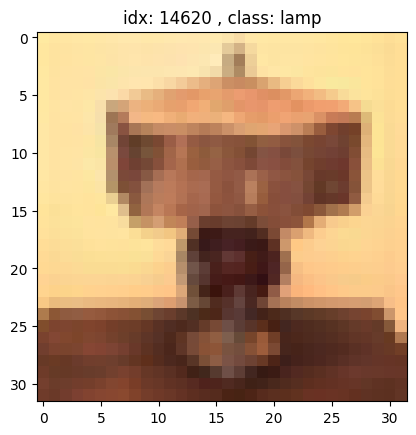

In [6]:
rand_i = np.random.randint(0, train_x.shape[0])

plt.title(f'idx: {rand_i} , class: { label_dict[train_y[rand_i][0]] }')
plt.imshow( train_x[rand_i] )
plt.show()

In [7]:
# rows = 5
# fig, axes = plt.subplots(rows, len(label_dict), figsize=(len(label_dict), rows) )

# for img_id in range(len(label_dict)) :
#     imgs = train_x[train_y.reshape(-1)==img_id]
#     imgs_len = len(imgs)

#     for row_i in range(rows) :
#         axe = axes[row_i, img_id]
#         axe.imshow( imgs[np.random.randint(imgs_len)], interpolation='none' )
#         axe.axis('off')

# plt.tight_layout()
# plt.show()

## Data Preprocessing

* Data split
    - training set : validation set = 8 : 2
    - 재현을 위한 난수 고정 : 2024

In [8]:
from sklearn.model_selection import train_test_split

train_x, val_x, train_y, val_y = train_test_split(train_x, train_y, test_size=0.2, random_state=2024)

In [9]:
train_x.shape, train_y.shape, val_x.shape, val_y.shape

((40000, 32, 32, 3), (40000, 1), (10000, 32, 32, 3), (10000, 1))

* Scaling <- PASS

    - min-max scaling
        1. RGB 정보 전체를 min-max

In [10]:
# min_n, max_n = train_x.min(), train_x.max()

In [11]:
# train_x = (train_x - min_n) / (max_n - min_n)
# val_x = (val_x - min_n) / (max_n - min_n)
# test_x = (test_x - min_n) / (max_n - min_n)

In [12]:
# train_x.min(), train_x.max()

* One-hot encoding <- PASS

In [13]:
# from keras.utils import to_categorical

In [14]:
# train_y = to_categorical(train_y, 100)
# val_y = to_categorical(val_y, 100)
# test_y = to_categorical(test_y, 100)

* Data shape 재확인

In [15]:
train_x.shape, train_y.shape, val_x.shape, val_y.shape

((40000, 32, 32, 3), (40000, 1), (10000, 32, 32, 3), (10000, 1))

## Modeling : CNN + **Image Precessing&Augmentation**

- 조건
    1. Sequential API, Functional API 중 택일.
    2. Image Augmentation Layer를 최소 하나 이상 넣을 것! : [공식 문서 참고](https://keras.io/api/layers/preprocessing_layers/)
    3. [이 구조를 미니 버전으로 활용해봐도 좋다.](https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Ft1.daumcdn.net%2Fcfile%2Ftistory%2F99DFA5415B38AC752E)
    4. DropOut, BatchNormalization 등의 기능도 같이 활용해보자.
    5. Early Stopping을 사용할 것.
      - compile 과정을 깊게 생각하세요 !:)

In [16]:
import keras

from keras.utils import clear_session, plot_model
from keras.models import Sequential, Model
from keras.layers import Input, Dense, Flatten, Conv2D, MaxPool2D, Dropout, BatchNormalization
from keras.layers import RandomRotation, RandomTranslation, RandomZoom, RandomFlip
from keras.callbacks import EarlyStopping

In [17]:
## Sequential API

# 세션 클리어
clear_session()

# 모델 선언 및 레이어 블록 조립
model = Sequential([Input(shape = (32, 32, 3)),
                    #####################################################################
                    ## Keras에서 제공하는 Augmentation Layer는 Input 바로 아래에 있어야 합니다!
                    RandomRotation(0.1),    # 10% 정도
                    RandomZoom(0.1),
                    RandomFlip('horizontal'),
                    #####################################################################
                    Conv2D(64, 3, 1, 'same', activation='relu'),
                    Conv2D(64, 3, 1, 'same', activation='relu'),
                    MaxPool2D(2),
                    BatchNormalization(),
                    Dropout(0.4),

                    Conv2D(128, 3, 1, 'same', activation='relu'),
                    Conv2D(128, 3, 1, 'same', activation='relu'),
                    MaxPool2D(2),
                    BatchNormalization(),
                    Dropout(0.4),

                    Flatten(),

                    Dense(512, activation='relu'),
                    Dense(100, activation='softmax')
                   ])
# 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_rotation (RandomRotation)     │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,507,044 (17.19 MB)

 Trainable params: 4,506,660 (17.19 MB)

 Non-trainable params: 384 (1.50 KB)

In [18]:
## Functional API
# 1. 세션 클리어
clear_session()

# 2. 레이어 엮기
il = Input(shape=(32,32,3))
###########################
# Augmentation Layer부터 적용
al = RandomRotation(0.1)(il)
al = RandomZoom(0.1)(al)
al = RandomFlip('horizontal')(al)
###########################
hl = Conv2D(64, 3, 1, 'same', activation='relu')(al)
hl = Conv2D(64, 3, 1, 'same', activation='relu')(hl)
hl = MaxPool2D(2)(hl)
hl = BatchNormalization()(hl)
hl = Dropout(0.4)(hl)

# hl = Conv2D(128, 3, 1, 'same', activation='relu')(al) ## plot_model로 현상을 보기위해 잠시 al로 해봄!
hl = Conv2D(128, 3, 1, 'same', activation='relu')(hl)
hl = Conv2D(128, 3, 1, 'same', activation='relu')(hl)
hl = MaxPool2D(2)(hl)
hl = BatchNormalization()(hl)
hl = Dropout(0.4)(hl)

hl = Flatten()(hl)
hl = Dense(512, activation='relu')(hl)
ol = Dense(100, activation='softmax')(hl)

# 3. 모델 시작, 끝 레이어 지정
model = Model(il, ol)

# 요약
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 32, 32, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 16, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 8, 8, 128)           │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 8, 8, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       4,194,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          51,300 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,507,044 (17.19 MB)

 Trainable params: 4,506,660 (17.19 MB)

 Non-trainable params: 384 (1.50 KB)

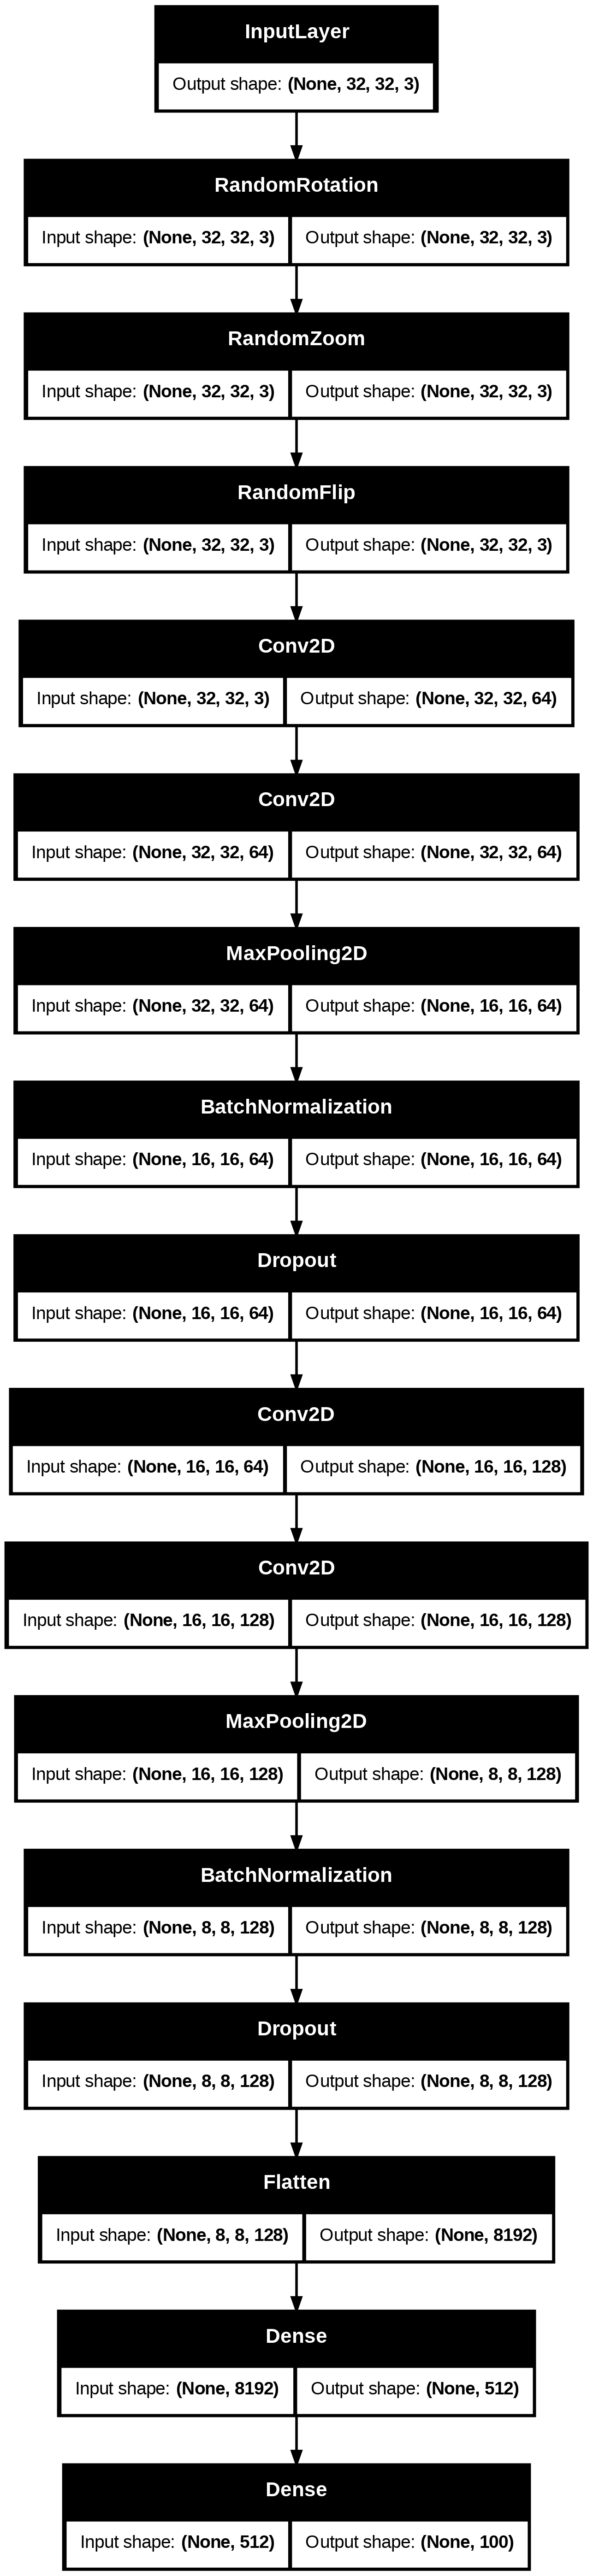

In [19]:
plot_model(model, show_shapes=True)

In [20]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', ## one-hot encoding 안 하였을 때!!
              metrics=['accuracy']
              )

* Early Stopping

In [21]:
from keras.callbacks import EarlyStopping

In [22]:
es = EarlyStopping(patience=3, verbose=1, restore_best_weights=True)

* .fit( )

In [23]:
model.fit(train_x, train_y, validation_data=(val_x, val_y),
          epochs=1000, verbose=1,
          callbacks=[es]
          )

Epoch 1/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.0697 - loss: 4.2760 - val_accuracy: 0.1423 - val_loss: 3.8428
Epoch 2/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 15ms/step - accuracy: 0.1680 - loss: 3.4798 - val_accuracy: 0.1988 - val_loss: 3.3414
Epoch 3/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.2128 - loss: 3.1995 - val_accuracy: 0.2418 - val_loss: 3.1285
Epoch 4/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.2554 - loss: 3.0092 - val_accuracy: 0.2675 - val_loss: 2.9238
Epoch 5/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.2807 - loss: 2.8652 - val_accuracy: 0.2925 - val_loss: 2.8512
Epoch 6/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.3004 - loss: 2.7604 - val_accuracy: 0.2850 - val_loss: 2.8376
Epoch 7/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.3144 - loss: 2.6746 - val_accuracy: 0.3348 - val_loss: 2.6182
Epoch 8/1000
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - ac

* .evaluate( )

In [24]:
model.evaluate(test_x, test_y)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4567 - loss: 2.1219


[2.1280312538146973, 0.4553999900817871]

* .predict( )

In [25]:
y_pred = model.predict(test_x)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [26]:
# 원핫 인코딩 한 것을 다시 묶어주는 코드
# 평가 지표 및 실제 데이터 확인을 위해 필요

y_pred_arg = np.argmax(y_pred, axis=1)
test_y_arg = test_y

In [27]:
y_pred_arg[0]

95

In [28]:
test_y_arg[0]

array([49])

* 평가 지표

In [29]:
from sklearn.metrics import accuracy_score, classification_report

In [30]:
accuracy_score(test_y_arg, y_pred_arg)

0.4554

In [31]:
print( classification_report(test_y_arg, y_pred_arg, target_names=list(label_dict.values())) )

               precision    recall  f1-score   support

        apple       0.73      0.77      0.75       100
aquarium_fish       0.67      0.41      0.51       100
         baby       0.54      0.22      0.31       100
         bear       0.34      0.23      0.28       100
       beaver       0.32      0.29      0.31       100
          bed       0.45      0.48      0.46       100
          bee       0.56      0.57      0.56       100
       beetle       0.53      0.57      0.55       100
      bicycle       0.34      0.74      0.47       100
       bottle       0.51      0.56      0.54       100
         bowl       0.34      0.28      0.31       100
          boy       0.27      0.24      0.25       100
       bridge       0.57      0.47      0.51       100
          bus       0.43      0.36      0.39       100
    butterfly       0.38      0.44      0.41       100
        camel       0.26      0.32      0.29       100
          can       0.48      0.46      0.47       100
       ca

## Visualization

* 실제 데이터 확인

idx = 4663
해당 인덱스의 이미지는 tractor
모델의 예측 : tractor
모델의 클래스별 확률 : 
-------------------
apple 0.0
aquarium_fish 0.0
baby 0.0
bear 0.0
beaver 0.0
bed 0.0
bee 0.0
beetle 0.0
bicycle 4.0
bottle 0.0
bowl 0.0
boy 0.0
bridge 0.0
bus 1.0
butterfly 0.0
camel 0.0
can 0.0
castle 12.0
caterpillar 0.0
cattle 0.0
chair 0.0
chimpanzee 0.0
clock 0.0
cloud 0.0
cockroach 0.0
couch 0.0
cra 0.0
crocodile 0.0
cup 0.0
dinosaur 1.0
dolphin 0.0
elephant 0.0
flatfish 0.0
forest 0.0
fox 0.0
girl 0.0
hamster 0.0
house 5.0
kangaroo 0.0
keyboard 0.0
lamp 0.0
lawn_mower 0.0
leopard 0.0
lion 0.0
lizard 0.0
lobster 0.0
man 0.0
maple_tree 0.0
motorcycle 1.0
mountain 0.0
mouse 0.0
mushroom 0.0
oak_tree 0.0
orange 0.0
orchid 0.0
otter 0.0
palm_tree 0.0
pear 0.0
pickup_truck 0.0
pine_tree 0.0
plain 0.0
plate 0.0
poppy 0.0
porcupine 0.0
possum 0.0
rabbit 0.0
raccoon 0.0
ray 0.0
road 0.0
rocket 0.0
rose 0.0
sea 0.0
seal 0.0
shark 0.0
shrew 0.0
skunk 0.0
skyscraper 0.0
snail 0.0
snake 0.0
spider 0.0
squirrel 0.0
streetcar 0.0


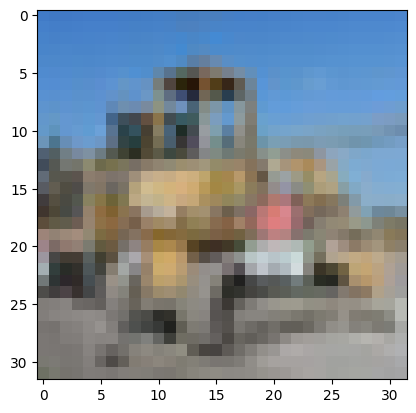

In [32]:
rand_idx = np.random.randint(0, len(y_pred_arg))
test_idx = test_y_arg[rand_idx]
pred_idx = y_pred_arg[rand_idx]
class_prob = np.floor( y_pred[rand_idx]*100 )

print(f'idx = {rand_idx}')
print(f'해당 인덱스의 이미지는 {label_dict[test_idx[0]]}')
print(f'모델의 예측 : {label_dict[pred_idx]}')
print(f'모델의 클래스별 확률 : ')
print('-------------------')
for idx, val in enumerate( list(label_dict.values()) ) :
    print(val, class_prob[idx])
print('=================================================')

if test_y_arg[rand_idx] == y_pred_arg[rand_idx] :
    print('정답')
else :
    print('땡')

plt.imshow(test_x[rand_idx])
plt.show()

* 틀린 이미지만 확인해보기

In [33]:
temp = (test_y_arg == y_pred_arg)
false_idx = np.where(temp==False)[0]
false_len = len(false_idx)
false_len

99000000

idx = 3440
해당 인덱스의 이미지는 palm_tree
모델의 예측 : palm_tree
모델의 클래스별 확률 : 
-------------------
apple 0.0
aquarium_fish 0.0
baby 0.0
bear 0.0
beaver 0.0
bed 0.0
bee 0.0
beetle 0.0
bicycle 0.0
bottle 0.0
bowl 0.0
boy 0.0
bridge 0.0
bus 0.0
butterfly 0.0
camel 0.0
can 0.0
castle 0.0
caterpillar 0.0
cattle 0.0
chair 0.0
chimpanzee 0.0
clock 0.0
cloud 0.0
cockroach 0.0
couch 0.0
cra 0.0
crocodile 0.0
cup 0.0
dinosaur 0.0
dolphin 0.0
elephant 0.0
flatfish 0.0
forest 0.0
fox 0.0
girl 0.0
hamster 0.0
house 0.0
kangaroo 0.0
keyboard 0.0
lamp 0.0
lawn_mower 0.0
leopard 0.0
lion 0.0
lizard 0.0
lobster 0.0
man 0.0
maple_tree 0.0
motorcycle 0.0
mountain 0.0
mouse 0.0
mushroom 0.0
oak_tree 0.0
orange 0.0
orchid 0.0
otter 0.0
palm_tree 86.0
pear 0.0
pickup_truck 0.0
pine_tree 0.0
plain 0.0
plate 0.0
poppy 0.0
porcupine 0.0
possum 0.0
rabbit 0.0
raccoon 0.0
ray 0.0
road 0.0
rocket 4.0
rose 0.0
sea 0.0
seal 0.0
shark 0.0
shrew 0.0
skunk 0.0
skyscraper 0.0
snail 0.0
snake 0.0
spider 0.0
squirrel 0.0
streetcar 

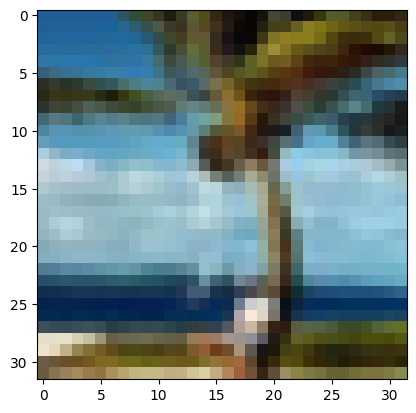

In [34]:
rand_idx = false_idx[np.random.randint(0, false_len)]
test_idx = test_y_arg[rand_idx]
pred_idx = y_pred_arg[rand_idx]
class_prob = np.floor( y_pred[rand_idx]*100 )

print(f'idx = {rand_idx}')
print(f'해당 인덱스의 이미지는 {label_dict[test_idx[0]]}')
print(f'모델의 예측 : {label_dict[pred_idx]}')
print(f'모델의 클래스별 확률 : ')
print('-------------------')
for idx, val in enumerate( list(label_dict.values()) ) :
    print(val, class_prob[idx])
print('=================================================')

if test_y_arg[rand_idx] == y_pred_arg[rand_idx] :
    print('정답')
else :
    print('땡')

plt.imshow(test_x[rand_idx] )
plt.show()